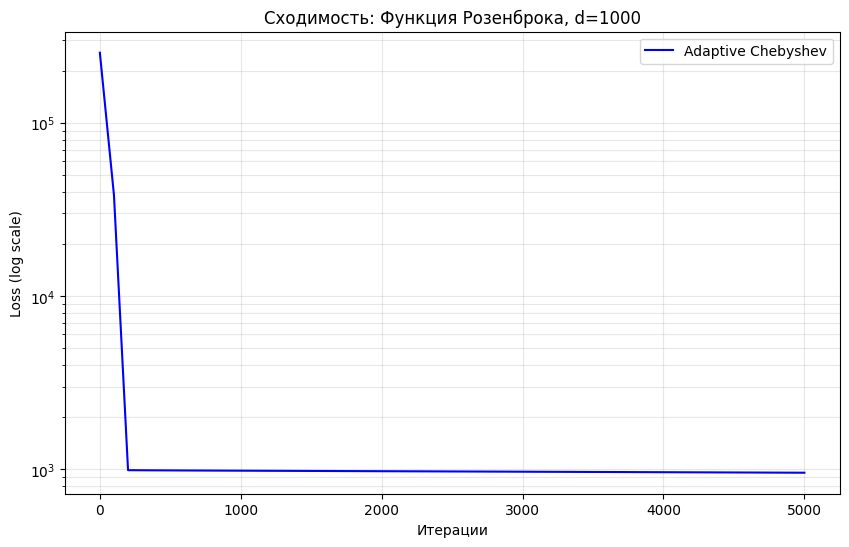

Размерность задачи: 1000
Финальное значение функции: 953.6080482812


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1.0 - x[:-1])**2.0)

# Градиент
def rosen_grad(x):
    g = np.zeros_like(x)
    xm = x[:-1]
    xp = x[1:]
    g[:-1] += -400 * xm * (xp - xm**2) - 2 * (1 - xm)
    g[1:] += 200 * (xp - xm**2)
    return g
# Произведение гессиана на вектор (HVP)
def rosen_hvp(x, v):
    n = len(x)
    hvp = np.zeros_like(x)

    xm = x[:-1]
    xp = x[1:]

    h11 = 1200 * xm**2 - 400 * xp + 2
    h22 = 200.0
    h12 = -400 * xm

    hvp[:-1] += h11 * v[:-1] + h12 * v[1:]
    hvp[1:] += h12 * v[:-1] + h22 * v[1:]

    return hvp

def solve_stable(x0, iterations=2000):
    x = x0.copy()
    n = len(x)
    history = [rosenbrock(x)]

    v_max = np.random.randn(n)
    v_max /= np.linalg.norm(v_max)
    v_min = np.random.randn(n)
    v_min /= np.linalg.norm(v_min)

    # На нулевой итерации для точности необходимо многократно умножать гессиан на вектор
    for _ in range(20):
        y_max = rosen_hvp(x, v_max)
        v_max = y_max / (np.linalg.norm(y_max) + 1e-12)
        lam_max = np.abs(v_max @ rosen_hvp(x, v_max))

        y_shift = lam_max * v_min - rosen_hvp(x, v_min)
        v_min = y_shift / (np.linalg.norm(y_shift) + 1e-12)

    # Далее достаточно одного HVP
    for it in range(iterations):
        g = rosen_grad(x)
        norm_g = np.linalg.norm(g)
        if norm_g < 1e-7:
            print(f"Сходимость достигнута на итерации {it}")
            break

        # Наибольшее собственное число
        y_max = rosen_hvp(x, v_max)
        norm_y_max = np.linalg.norm(y_max)
        v_max = y_max / (norm_y_max + 1e-12)
        lam_max = np.abs(v_max @ y_max)

        # Наименьшее собственное число через спектральный шифтинг
        y_shift = lam_max * v_min - rosen_hvp(x, v_min)
        v_min = y_shift / (np.linalg.norm(y_shift) + 1e-12)
        sigma = np.abs(v_min @ y_shift)
        lam_min = np.abs(lam_max - sigma)

        # Шаг
        eta = 2.0 / (lam_max + lam_min + 1e-6)
        x = x - eta * g
        if it % 100 == 0:
            history.append(rosenbrock(x))

    return history

# Размерность
d = 1000
# Традиционная стартовая точка для Розенброка: (-1.2, 1, -1.2, 1...)
x_start = np.ones(d)
x_start[::2] = -1.2

history = solve_stable(x_start, iterations=5000)

plt.figure(figsize=(10, 6))
plt.semilogy(np.arange(len(history))*100, history, color='blue', label='Adaptive Chebyshev')
plt.title(f'Сходимость: Функция Розенброка, d={d}')
plt.xlabel('Итерации')
plt.ylabel('Loss (log scale)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

print(f"Размерность задачи: {d}")
print(f"Финальное значение функции: {history[-1]:.10f}")